# Market Base
<!-- [![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AAM26-G02/market-base/blob/main/notebooks/market_base.ipynb) --> 

| ***Campo*** | ***Detalle*** |
| :--- | :--- |
| **Asignatura** | Aprendizaje Automático y Minería de Datos  |
| **Profesor** | Federico Peinado Gil |
| **Autores** | Carmen Gómez Becerra (@acostacion) y Denisa Juarranz Berindea (@M00nHun7r3ss) |
| **Institución** | Universidad Complutense de Madrid |
| **Licencia** | Copyright © 2026 Federico Peinado. Distribuido bajo licencia [MIT](https://opensource.org/licenses/MIT) |
| **Requisitos** | Python 3.x (Módulos nativos, sin dependencias externas) | 

Este punto de partida está pensado para prácticas sobre Minería de Datos. Antes de alimentar cualquier modelo analítico o de aprendizaje automático, es imprescindible adquirir, limpiar, explorar y visualizar a fondo los datos. 

### Características del estudio
A. Adquisición del conjunto de datos y exploración inicial
B. Valoración de la calidad de datos, limpieza e ingeniería de características
C. Análisis de variables
D. Análisis de correlaciones y serie temporal
E. Nichos de oportunidad y conclusiones

## 🛠️ Configuración Inicial e Importación de Librerías

In [3]:
import os # Para interactuar con el sistema operativo
import urllib.request  # Para descargar archivos desde la web
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo gráfico
sns.set_theme(style="whitegrid") # Un estilo más limpio y profesional para los gráficos
plt.rcParams['figure.figsize'] = (10, 6) # Para evitar que los gráficos se vean demasiado pequeños

print("Bibliotecas cargadas correctamente.")

Bibliotecas cargadas correctamente.


## A. Adquisición del conjunto de datos y exploración inicial

**Objetivo:** Descargar el conjunto de datos directamente desde el repositorio del proyecto en la carpeta local `data/raw/` y verificar que la estructura de columnas y tipos de datos se haya cargado correctamente sin desfases en la cabecera.

In [4]:
# 1. Rutas locales y URL oficial
PROJECT_ROOT = os.path.abspath(os.path.join(".."))
RAW_DATA_DIR = os.path.join(PROJECT_ROOT, "data", "raw")
LOCAL_CSV_PATH = os.path.join(RAW_DATA_DIR, "games.csv")
DATASET_URL = "https://github.com/narratech/market-base/releases/download/Release/games.csv"

# 2. Descarga automatizada a data/raw/
if not os.path.exists(LOCAL_CSV_PATH):
    os.makedirs(RAW_DATA_DIR, exist_ok=True)
    print("Descargando games.csv desde el repositorio...")
    urllib.request.urlretrieve(DATASET_URL, LOCAL_CSV_PATH)
    print(f"¡Descarga completada en {LOCAL_CSV_PATH}!")
else:
    print(f"El archivo ya existe en {LOCAL_CSV_PATH}.")

# 3. Carga del DataFrame
print("Cargando el archivo en memoria")
df = pd.read_csv(LOCAL_CSV_PATH)
print("DataFrame cargado correctamente y listo para la exploración")

El archivo ya existe en c:\Users\Denisa\Desktop\Universidad\Tercero\AAM26-G02-P1\data\raw\games.csv.
Cargando el archivo en memoria
DataFrame cargado correctamente y listo para la exploración


In [5]:
# Muestra las dimensiones del DataFrame...
print(f"\033[35m✧ Dimensiones del DataFrame ✧\033[0m {df.shape}\n")

# ... sus primeras filas...
print("\033[35m⛧ °。 ⋆༺♱༻⋆。 °⛧")
print("✧ Primeras filas ✧")
print("⛧ °。 ⋆༺⚸༻⋆。 °⛧\033[0m")
df.head()
print("\n")

# ... y el resumen de información técnica (dtypes, valores no nulos).
print("\033[35m⛧ °。 ⋆༺♱༻⋆。 °⛧")
print("✧ Resumen de información técnica ✧") 
print("⛧ °。 ⋆༺⚸༻⋆。 °⛧\033[0m")
df.info()
print("\n")

# Cantidad de datos ausentes, faltantes o nulos.
print("\033[35m⛧ °。 ⋆༺♱༻⋆。 °⛧")
print("✧ Cantidad de valores nulos ✧") 
print("⛧ °。 ⋆༺⚸༻⋆。 °⛧\033[0m")
print(df.isnull().sum())

✧ Dimensiones del DataFrame ✧ (125855, 39)

⛧ °。 ⋆༺♱༻⋆。 °⛧
✧ Primeras filas ✧
⛧ °。 ⋆༺⚸༻⋆。 °⛧


⛧ °。 ⋆༺♱༻⋆。 °⛧
✧ Resumen de información técnica ✧
⛧ °。 ⋆༺⚸༻⋆。 °⛧
<class 'pandas.DataFrame'>
Index: 125855 entries, 2539430 to 4247310
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       125854 non-null  str    
 1   Name                        125855 non-null  str    
 2   Release date                125855 non-null  str    
 3   Estimated owners            125855 non-null  int64  
 4   Peak CCU                    125855 non-null  int64  
 5   Required age                125855 non-null  float64
 6   Price                       125855 non-null  int64  
 7   DiscountDLC count           125855 non-null  int64  
 8   About the game              117393 non-null  str    
 9   Supported languages         125855 non-null  str    
 10  Full audio languages        125855 no

> **Discusión**  
> *Redacta aquí tus observaciones sobre la estructura de los datos, número de registros, alineación de cabeceras o columnas con tipos de datos no optimizados.*

---

## B. Valoración de la calidad de datos, limpieza e ingeniería de características

**Objetivo:** Tratar valores nulos, transformar tipos de datos (como la conversión de cadenas de texto separadas por comas a listas iterables) y calcular nuevas métricas como la tasa de valoraciones positivas, aplicando un filtrado adecuado para evitar sesgos por bajo volumen de reseñas.

In [1]:
"""
# TODO: Tratamiento de nulos y conversión de tipos de datos (ej. cadenas a listas para géneros/tags)
# Escribe tu código aquí:
print("\033[35m⛧ °。 ⋆༺♱༻⋆。 °⛧")
print("✧ Tratamiento de nulos ✧")
print("⛧ °。 ⋆༺⚸༻⋆。 °⛧\033[0m\n")

# Detectar nulos y porcentajes por columna
print("\033[35m✧ Porcentaje de nulos antes de tratarse ✧\033[0m")
print(df.isnull().mean() * 100)
print("\n")

# Estrategia 1: Eliminar filas con nulos (si son muy pocos)
df_limpio = df.dropna(subset=["AppID", "About the game", "Header image", "Developers", "Publishers", "Categories", "Genres", "Screenshots"]) # nulos [0, 10]

# Estrategia 2: Imputación simple con Pandas
# si es string, bool -> "desconocido" o moda # Duda: bool donde entra
# si es int64, float64 -> media o mediana
df_limpio["Reviews"] = df_limpio["Reviews"].fillna("Desconocido") # Duda: que es mejor desconocido, moda o ir intercalando
df_limpio["Website"] = df_limpio["Website"].fillna("Desconocido")
df_limpio["Support url"] = df_limpio["Support url"].fillna("Desconocido")
df_limpio["Support email"] = df_limpio["Support email"].fillna("Desconocido")
df_limpio["Metacritic url"] = df_limpio["Metacritic url"].fillna("Desconocido")
df_limpio["Score rank"] = df_limpio["Score rank"].fillna(df_limpio["Score rank"].median()) # Duda: es mejor media o mediana (no tiene casi valores tampoco pero ns k hacerle)
df_limpio["Notes"] = df_limpio["Notes"].fillna("Desconocido")
df_limpio["Tags"] = df_limpio["Tags"].fillna("Desconocido")
df_limpio["Movies"] = df_limpio["Movies"].fillna("Desconocido") # Duda: ns k hacer pork no tiene valores 

print("\033[35m✧ Porcentaje de nulos tras tratarse ✧\033[0m")
print(df_limpio.isnull().mean() * 100) 
print("\n")

print("\033[35m⛧ °。 ⋆༺♱༻⋆。 °⛧")
print("✧ Transformar tipos de datos ✧")
print("⛧ °。 ⋆༺⚸༻⋆。 °⛧\033[0m\n")

# 1. Parseo de cadenas y limpieza de texto/símbolos (Números leídos como cadenas de texto) # Duda: k hay k hacer con APPID # Duda: supported langugages esta bn? o es con lo de las comas, como tiene k separarse
df["precio"] = df["precio"].astype(str).str.replace("$", "").str.replace(",", "").astype(float) # TODO cambiar
#categories, genres, tags y creo k ya


# 2. Convertir a tipo datetime y extracción de partes temportales (.dt) (Fechas leídas como cadenas de texto)
df_limpio["Release date"] = pd.to_datetime(df_limpio["Release date"])
df_limpio["Release year"] = df_limpio["Release date"].dt.year # crea nueva columna k es el anio k salio pork sale en el ejemplo k ns si hay k hacerlo pero bueno

# 3. Eliminar duplicados explícitos (Muestras idénticas o con variaciones tipográficas)
df_limpio = df_limpio.drop_duplicates()

# -------------------------------------------------------- codigo de federico peinado jajjj
df = df_raw.copy() # hacemos una copia para no modificar el dataframe original

# eliminar columnas k no necesitamos para el analisis
cols_a_eliminar = ['Website', 'Movies', 'Notes']; # lo k no keramos fuera, lo kitamos
df.drop(columns=cols_a_eliminar, inplace=True)

df['Release date'] = pd.to_datetime(df['Release date'], format="mixed", errors='coerce')

cols_texto = ['NameError', 'Developers', 'Publishers', 'Genres', 'Categories', 'Tags']
for col in cols_texto:
    df[col] = df[col].fillna('Unknown')

def cadena_a_lista(cadena):
        if isinstance(cadena, str) and cadena != 'Unknown': # verifica si es NaN
                return[item.strip() for item in cadena.split(',')]
        return[]

for col in ['Genres', 'Categories', 'Tags']:
       df[col] = df[col].apply(cadena_a_lista)

"""

'\n# TODO: Tratamiento de nulos y conversión de tipos de datos (ej. cadenas a listas para géneros/tags)\n# Escribe tu código aquí:\nprint("\x1b⛧ °。 ⋆༺♱༻⋆。 °⛧")\nprint("✧ Tratamiento de nulos ✧")\nprint("⛧ °。 ⋆༺⚸༻⋆。 °⛧\x1b\n")\n\n# Detectar nulos y porcentajes por columna\nprint("\x1b✧ Porcentaje de nulos antes de tratarse ✧\x1b")\nprint(df.isnull().mean() * 100)\nprint("\n")\n\n# Estrategia 1: Eliminar filas con nulos (si son muy pocos)\ndf_limpio = df.dropna(subset=["AppID", "About the game", "Header image", "Developers", "Publishers", "Categories", "Genres", "Screenshots"]) # nulos [0, 10]\n\n# Estrategia 2: Imputación simple con Pandas\n# si es string, bool -> "desconocido" o moda # Duda: bool donde entra\n# si es int64, float64 -> media o mediana\ndf_limpio["Reviews"] = df_limpio["Reviews"].fillna("Desconocido") # Duda: que es mejor desconocido, moda o ir intercalando\ndf_limpio["Website"] = df_limpio["Website"].fillna("Desconocido")\ndf_limpio["Support url"] = df_limpio["Support u

In [ ]:
# TODO: Crear la característica 'tasa_positividad' filtrando solo juegos con más de 50 reseñas totales
# Escribe tu código aquí:


> **Discusión**  
> *Explica el impacto del tratamiento de nulos y justifica cuantitativamente por qué es técnicamente necesario filtrar por un volumen mínimo de reseñas (50) para evitar distorsiones en la métrica de positividad.*

---

## C. Análisis de variables

**Objetivo:** Analizar los géneros más frecuentes en oferta frente a su volumen estimado de jugadores. Analizar estadísticamente la distribución de precios en la plataforma.

✧ Top 10 Géneros más Frecuentes (Absoluta) ✧
Genres
Casual,Indie              6912
Action,Indie              5802
Action,Adventure,Indie    5259
Adventure,Indie           4422
Adventure,Casual,Indie    3691
Action,Casual,Indie       3484
Casual                    3448
Indie                     3175
Action                    3037
Casual,Indie,Strategy     2327
Name: count, dtype: int64

✧ Top 10 Géneros más Frecuentes (Relativa %) ✧
Genres
Casual,Indie              5.89
Action,Indie              4.94
Action,Adventure,Indie    4.48
Adventure,Indie           3.77
Adventure,Casual,Indie    3.14
Action,Casual,Indie       2.97
Casual                    2.94
Indie                     2.70
Action                    2.59
Casual,Indie,Strategy     1.98
Name: proportion, dtype: float64


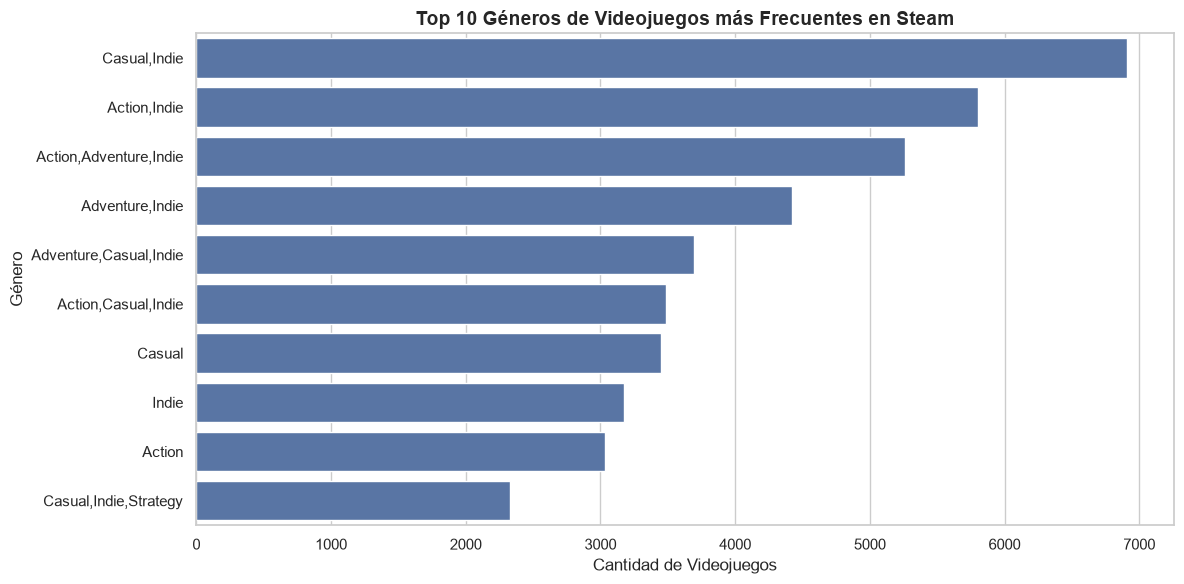

In [11]:
# Desempaquetado de géneros y cálculo de frecuencias absolutas y relativas.
# Generar gráfico de barras del Top 10 de géneros.

# 1. Separar los géneros si vienen juntos por comas y desempaquetarlos
df_genres = df['Genres'].dropna().astype(str).str.split(', ')
df_genres_exploded = df_genres.explode()

# 3. Calcular frecuencias absolutas y relativas
frec_absoluta = df_genres_exploded.value_counts()
frec_relativa = df_genres_exploded.value_counts(normalize=True) * 100

print("\033[35m✧ Top 10 Géneros más Frecuentes (Absoluta) ✧\033[0m")
print(frec_absoluta.head(10))
print("\n\033[35m✧ Top 10 Géneros más Frecuentes (Relativa %) ✧\033[0m")
print(frec_relativa.head(10).round(2))

# 4. Gráfico de barras del Top 10 de géneros
plt.figure(figsize=(12, 6))
sns.barplot(x=frec_absoluta.head(10).values, y=frec_absoluta.head(10).index)
plt.title("Top 10 Géneros de Videojuegos más Frecuentes en Steam", fontsize=14, fontweight='bold')
plt.xlabel("Cantidad de Videojuegos")
plt.ylabel("Género")
plt.tight_layout()
plt.show()

✧ Resumen de Mercado ✧
Juegos Gratuitos: 85045 (67.57%)
Juegos de Pago: 40810 (32.43%)

✧ Estadísticos Descriptivos (Juegos de Pago) ✧
Media (Precio promedio): 55.19 €
Mediana (Precio central): 51.00 €
Desviación Estándar: 21.66 €
Mínimo: 10.00 €
Máximo: 100.00 €
Rango Intercuartílico (IQR): 35.00 € (El 50% de los juegos cuesta entre 40.00€ y 75.00€)


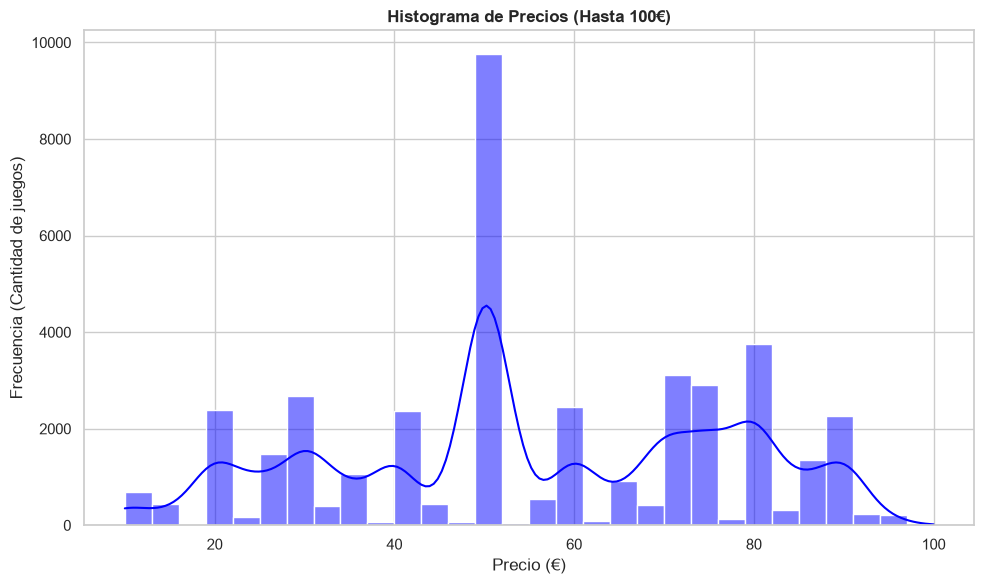

In [24]:
# Separar juegos de pago de los gratuitos. Calcular estadísticos descriptivos (media, mediana, IQR). 
# Generar un histograma/boxplot de la distribución de precios.

# 1. Separar juegos de pago de los gratuitos
juegos_gratuitos = df[df['Price'] == 0]
juegos_pago = df[df['Price'] > 0]

print(f"\033[35m✧ Resumen de Mercado ✧\033[0m")
print(f"Juegos Gratuitos: {len(juegos_gratuitos)} ({len(juegos_gratuitos)/len(df)*100:.2f}%)")
print(f"Juegos de Pago: {len(juegos_pago)} ({len(juegos_pago)/len(df)*100:.2f}%)\n")

# 3. Calcular estadísticos descriptivos para juegos de pago
stats_pago = juegos_pago[columna_precio].describe()
q1 = stats_pago['25%']
q3 = stats_pago['75%']
iqr = q3 - q1

print("\033[35m✧ Estadísticos Descriptivos (Juegos de Pago) ✧\033[0m")
print(f"Media (Precio promedio): {stats_pago['mean']:.2f} €")
print(f"Mediana (Precio central): {stats_pago['50%']:.2f} €")
print(f"Desviación Estándar: {stats_pago['std']:.2f} €")
print(f"Mínimo: {stats_pago['min']:.2f} €")
print(f"Máximo: {stats_pago['max']:.2f} €")
print(f"Rango Intercuartílico (IQR): {iqr:.2f} € (El 50% de los juegos cuesta entre {q1:.2f}€ y {q3:.2f}€)")

# 4. Gráficos de Distribución de Precios (Un solo gráfico)
plt.figure(figsize=(10, 6))

# Creamos el histograma directamente en el lienzo actual
sns.histplot(data=juegos_pago[juegos_pago[columna_precio] <= 100], x=columna_precio, bins=30, kde=True, color="blue")

# Configuramos las etiquetas del único gráfico
plt.title("Histograma de Precios (Hasta 100€)", fontsize=12, fontweight='bold')
plt.xlabel("Precio (€)")
plt.ylabel("Frecuencia (Cantidad de juegos)")

plt.tight_layout()
plt.show()


> **Discusión**  
> *Comenta qué género domina la oferta y si coincide con los más jugados. Explica la diferencia entre la media y la mediana en el precio para identificar el rango habitual de precios en Steam.*


> **Análisis de Géneros**   
> Los resultados demuestran que el mercado de Steam está plagado de videojuegos de género **Indie** combinados con otros géneros como **Casual, Action y Adventure**. La combinación más frecuente es `Casual,Indie` con un **5.89%** del total, seguida por `Action,Indie` con un **4.94%** del total.
> Esto nos indicaría que, de cada a un futuro juego, habrá mucha competencia si nuestra apuesta es un juego **Indie**, pues es lo que más se lleva

> **Distribución de Precios**   
> Como podemos comprobar, el público prefiere los juegos **gratuitos**, dado que representa el **67.57%** del mercado total en Steam. En cuanto al resto, un **32.43%** de usuarios eligen juegos de pago.
> Al profundizar en los videojuegos de pago, podemos observar datos más concluyentes:
>* **Mínimo y Máximo:** El umbral de pago comienza en los **10.00 €** y alcanza un tope de **100.00 €**.
>* **Media vs. Mediana:** El precio promedio (media) es de **55.19 €**, mientras que el precio central (mediana) está en **51.00 €**. Debido a que la media es ligeramente mayor que la mediana, confirmamos que la distribución tiene un leve sesgo hacia la derecha provocado por lanzamientos más caros.
>* **Horquilla Habitual (IQR):** El Rango Intercuartílico nos da a entender que **el 50% de los videojuegos de pago en Steam se comercializan en una horquilla de entre 40.00 € y 75.00 €**. 

---

## D. Análisis de correlaciones y serie temporal

**Objetivo:** Estudiar la relación cruzada entre el precio y el éxito del videojuego. Analizar la serie temporal de lanzamientos de juegos por año en Steam.

In [ ]:
# TODO: Calcular la matriz de correlación (ej. Spearman) entre precio, positividad y número de reseñas.
# Ej. Generar visualización (Heatmap o Scatter plot con tendencia).
# Escribe tu código aquí:


In [ ]:
# TODO: Extraer el año de lanzamiento de 'Release date' y analizar la evolución del catálogo de Steam año a año.
# Ej. Generar gráfico de línea/área.
# Escribe tu código aquí:


> **Discusión**  
> *¿Tienen los juegos más caros mejor valoración? Analiza los resultados de correlación y describe el ritmo de crecimiento anual de la plataforma.*

---

## E. Nichos de oportunidad y conclusiones

**Objetivo:** Identificar combinaciones o nichos de mercado con baja saturación de oferta pero alta tasa de positividad media (u otro análisis avanzado que queráis plantear) y sintetizar las conclusiones generales del estudio.

In [ ]:
# TODO: Código para cruzar géneros/tags poco saturados con altas valoraciones o análisis avanzado a elección.
# Escribe tu código aquí:


> **✏️ Conclusiones**  
> *Redacta un breve informe de cierre sintetizando los hallazgos clave obtenidos a lo largo de todo el estudio. Propón recomendaciones concretas basadas en datos para un nuevo estudio de desarrollo que quiera lanzar un juego en Steam.*